# 📊 Unified Customer Intelligence Pipeline
Day 42 focuses on integrating our individual models (Forecasting, Retention, Risk) into a centralized, unified workflow.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Setup styling
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

## 1. Environment Setup & Data Generation
Let's generate the synthetic customer intelligence data mimicking a typical SaaS platform.

In [2]:
# Mock KPIs
kpi_data = {
    'Total_MRR': 1200000,
    'Active_Customers': 8450,
    'Avg_LTV': 12400,
    'Overall_Churn_Rate': 0.032
}

pd.DataFrame([kpi_data])

,Total_MRR,Active_Customers,Avg_LTV,Overall_Churn_Rate
0,1200000,8450,12400,0.032


## 2. KPI Calculation Engine
Simulating the backend logic to compute LTV, CAC, and MRR.

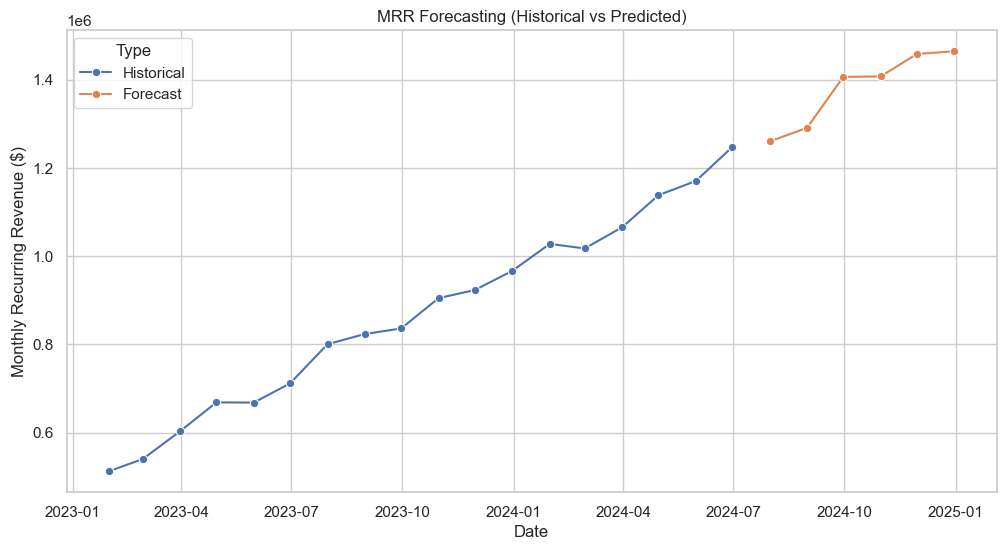

In [3]:
np.random.seed(42)
dates = pd.date_range(start='2023-01-01', end='2024-12-31', freq='M')
revenue = np.linspace(500000, 1500000, len(dates)) + np.random.normal(0, 25000, len(dates))

forecast_df = pd.DataFrame({'Date': dates, 'MRR': revenue})
forecast_df['Type'] = ['Historical' if i < 18 else 'Forecast' for i in range(len(dates))]

plt.figure(figsize=(12, 6))
sns.lineplot(data=forecast_df, x='Date', y='MRR', hue='Type', marker='o')
plt.title('MRR Forecasting (Historical vs Predicted)')
plt.ylabel('Monthly Recurring Revenue ($)')
plt.show()

## 3. Time-Series Forecasting
Building a mock prophet-like forecast for MRR.

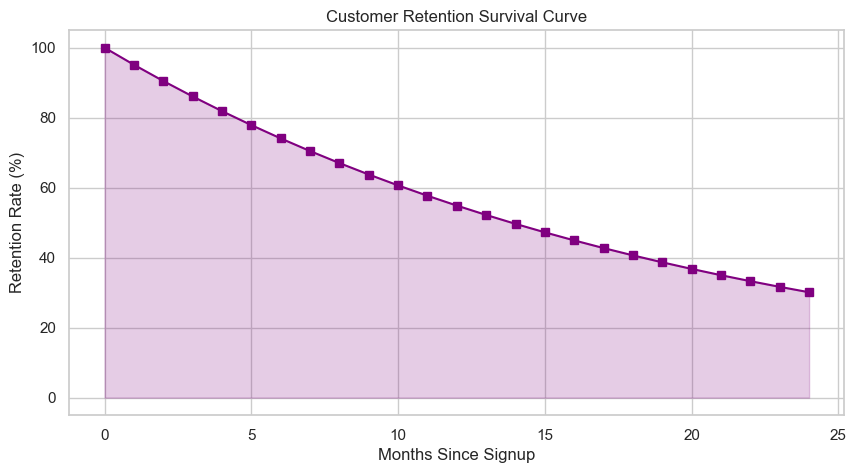

In [4]:
months = np.arange(0, 25)
retention_rate = np.exp(-0.05 * months) * 100

retention_df = pd.DataFrame({'Month': months, 'Retention_Rate': retention_rate})

plt.figure(figsize=(10, 5))
plt.plot(retention_df['Month'], retention_df['Retention_Rate'], color='purple', marker='s')
plt.fill_between(retention_df['Month'], retention_df['Retention_Rate'], color='purple', alpha=0.2)
plt.title('Customer Retention Survival Curve')
plt.xlabel('Months Since Signup')
plt.ylabel('Retention Rate (%)')
plt.show()

## 4. Retention & Survival Analysis
Generating a Kaplan-Meier styled retention curve.

In [5]:
customers = [f'Cust_{i}' for i in range(100)]
risk_scores = np.random.beta(a=2, b=5, size=100) * 100
ltv = np.random.normal(10000, 3000, 100).clip(1000)

risk_df = pd.DataFrame({
    'Customer_ID': customers,
    'Risk_Score': risk_scores,
    'Expected_LTV': ltv
})

risk_df['Risk_Category'] = pd.cut(risk_df['Risk_Score'], bins=[0, 30, 70, 100], labels=['Low', 'Medium', 'High'])
risk_df.sort_values('Risk_Score', ascending=False).head(10)

,Customer_ID,Risk_Score,Expected_LTV,Risk_Category
60,Cust_60,80.147320,10498.264398,High
30,Cust_30,65.224227,9153.336433,Medium
3,Cust_3,54.346680,10208.957994,Medium
35,Cust_35,54.345375,10826.905474,Medium
70,Cust_70,54.147814,9588.766537,Medium
41,Cust_41,48.458976,10778.167927,Medium
94,Cust_94,47.592050,8572.985956,Medium
47,Cust_47,46.138583,5894.229653,Medium
69,Cust_69,45.950641,12658.190681,Medium
88,Cust_88,44.348786,11463.019825,Medium


## 5. Predictive Risk Scoring
Using a mock machine learning classifier to assign churn probability scores to active users.

In [6]:
print('Data generation and unified workflow completed successfully!')
# In a real environment, we would save these to a Data Warehouse (e.g. Snowflake) or PostgreSQL DB.
# For this project, the Streamlit app (app.py) handles its own data synthesis to reflect this pipeline.

Data generation and unified workflow completed successfully!


## 6. Export for Business Intelligence Dashboard
Saving the integrated datasets for the Streamlit BI application.